<hr>

<center>
    Class: Machine Learning in Computational Biology <br>
    Program: Data Science and Information Technologies <br>
    Name: Aris <br>
    Las name: Podotas <br>
    ID: 7115152400040 <br>
    Assignment: 1 <br>
</center>

<hr>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append('../src/')
import functions as utils


<hr>

# Approach

A good way to transform our problem into a calssification problem is with a unsupervised classification approach (i.e. clustering). This is because the how many and where delimiters between the classes is unknown to us and arbitrary to chooose on our own. We will find the number of best clusters to represent the data and use those classes as ground truth for the models that do the classification.

## Clustering approach

Clustering is split into stages

- Feeling the data
- Feature selection/Transformation
- Selection of the clustering algorithms
- Execution of the algorithms
- Characterization of the cluters

I personally from experience like to insert a "Assumptions" segment before the execution of the algorithms.

We have already completed the first two steps of the workflow in the previous notebook. We proceed with the selection of the algorithms

## Selection of the algorithms

We know from previous work that

- The BMI has a few outliers, more so to the negative side than the positive side of the distribution
- The distribution of the BMI can be approximated via normal distribution.
- Not too many of the features have Pearson cross correlation between them.
- We can reduce the number of features in the set via PCA
- There is no validation set for the clustering problem, all data should be considered
- We only need to split the BMI into clusters which is one dimensional

With this in mind, we will determine the number of clusters with k-means clustering using point cluster representatives generated at the mean of the BMI data $\pm$ some very small random value.

Then we will clsuter the data using 

- k-means
- Expectation maximization
- DBSCAN
- single link
- complete link

I also would like some median clustering but it seems it is not provided in ```sklearn```.

## Assumptions

- Median based clustering will output better results since they will take into acount the outliers in our data
- Density based clustering algorithms will not perform well since our data clusters are not well separated
- The single link algorithm will not perform well since it captures elongated clusters and this will lead to it clustering discreet clusters together
- We will not have more clusters than the ones listed in the world health organisation webpage since there is no a-priori information in clustering for us

<hr>

In [2]:
# Getting data
dev = pd.read_csv('../data/development_final_data.csv')
val = pd.read_csv('../data/evaluation_final_data.csv')
devData, devMetaData = utils.dataSplit(dev)
valData, valMetaData = utils.dataSplit(val)
del devMetaData
del valMetaData

# Shaping data
train, preds = utils.isolator(devData)
validation, truth = utils.isolator(valData)

holder = utils.fitPca(train, 95)
devData = utils.applyPca(train, holder)
valData = utils.applyPca(validation, holder)
devPca = devData.copy()
valPca = valData.copy()
devData.insert(0, 'BMI', preds)
valData.insert(0, 'BMI', truth)
del holder
# We keep the other variables for later int the classification

data = pd.concat([devData, valData])
data.head(10)


Function 'dataSplit' executed in 0.0031 seconds
Function 'dataSplit' executed in 0.0000 seconds
Function 'isolator' executed in 0.0036 seconds
Function 'isolator' executed in 0.0000 seconds
Function 'fitPca' executed in 0.0742 seconds
Function 'applyPca' executed in 0.0075 seconds
Function 'applyPca' executed in 0.0051 seconds


,BMI,0,1,2,3,4,5,6,7,8,...,85,86,87,88,89,90,91,92,93,94
0,19.01,-1.849089,-0.140920,-1.266297,-0.145266,-0.301463,-0.185271,0.213756,-0.517308,-0.048592,...,0.123970,0.170621,-0.354964,0.045266,-0.038382,-0.016285,-0.029371,-0.259434,-0.052854,-0.128872
1,23.50,3.043090,10.763641,2.874763,-4.693270,-0.041211,-0.084973,-1.329089,-2.964214,1.211787,...,0.853981,0.112889,-0.410547,0.622230,0.798453,0.214674,-0.408864,1.077974,-0.788656,-0.528223
2,25.80,-2.403592,0.270338,-1.193480,-0.320505,-0.624223,-0.278452,-0.283442,-0.085687,-0.253455,...,0.019852,0.268311,-0.114725,-0.016287,-0.248290,0.059599,0.161361,0.267282,0.077818,-0.054439
3,23.49,0.610512,-0.157055,0.616014,1.940658,-0.451681,-1.180577,-0.962582,0.257780,0.158454,...,-0.709676,-0.949189,-0.670401,0.154740,-0.350549,2.171668,-0.275381,-0.637749,-0.614822,-0.220837
4,22.60,2.125645,-3.238797,-0.077841,-1.307018,-0.529641,-0.873104,-0.526120,-0.087158,-1.768089,...,0.481511,-0.104006,0.394107,-0.646282,-1.188266,0.232789,-0.613627,1.345919,-1.918396,0.882115
5,26.25,0.220411,0.111013,-1.959648,1.839166,-0.477472,0.651394,0.920852,1.095730,-0.815820,...,0.110772,-0.472097,-0.063358,0.434263,0.436164,-0.028380,-0.033991,0.048406,0.086467,0.021808
6,25.80,-3.417354,-0.393641,-0.753344,0.119673,-0.884706,1.036933,-0.599570,-0.140215,-0.476263,...,0.740540,-0.364239,-0.053757,-0.057995,0.307152,-0.401868,0.101187,-0.344328,0.088476,-0.303834
7,25.80,-2.397068,0.379508,-1.229359,-0.409367,-0.745467,-0.093351,-0.391664,0.090069,-0.571915,...,0.458757,0.343978,-0.268152,-0.072278,0.188407,-0.105393,0.089437,0.479032,0.072659,0.069647
8,24.75,0.417448,-0.620009,-2.654543,4.713648,-1.633240,1.547444,2.673279,3.963473,-3.747256,...,0.079895,-0.788334,0.510470,-0.055236,-0.518987,0.379301,0.303484,-0.859317,-0.289522,-0.649097
9,28.70,1.849559,0.711918,-0.625094,0.480615,-0.237318,0.189131,0.265887,-0.504149,-0.623961,...,-0.847773,-1.241507,1.075457,0.823198,-0.770480,1.263866,0.213631,-0.553740,0.126900,0.151229


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

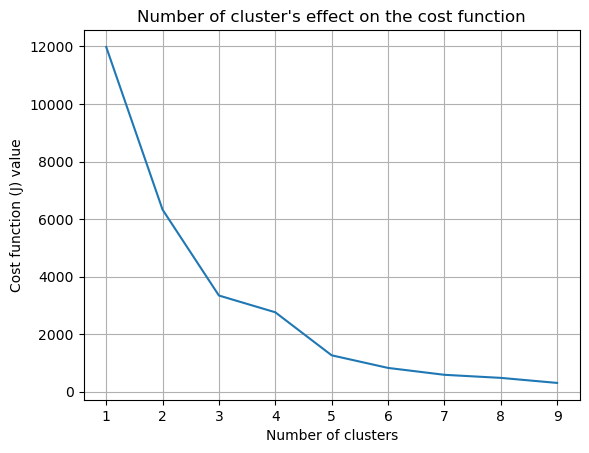

Function 'findClusters' executed in 1.2424 seconds


In [3]:
# For cluster representatives
utils.findClusters(data['BMI'], 10)


<hr>

The most significant knee in the plot shows the number of clusters. The final number of clusters is $3$.

<hr>

In [41]:
clustering = utils.applyKmeans(data['BMI'])


Function 'applyKmeans' executed in 0.1161 seconds


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


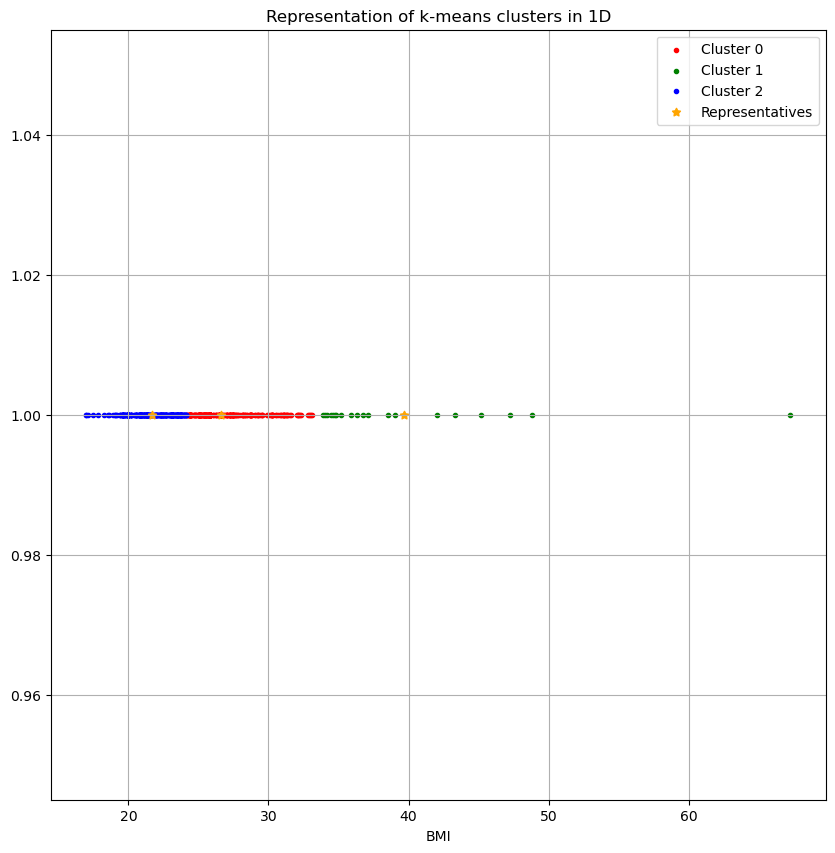

Function 'plotKmeans' executed in 0.2041 seconds


In [42]:
utils.plotKmeans(data['BMI'], clustering)
del clustering


<hr>

Now I am curious to see the clustering for more clusters since the weird rate of change in the plot of $J$ (the cost function) may be due to outliers pulling our representative and the actual cluster might be $4$ or $5$.

<hr>

C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Function 'applyKmeans' executed in 0.0938 seconds


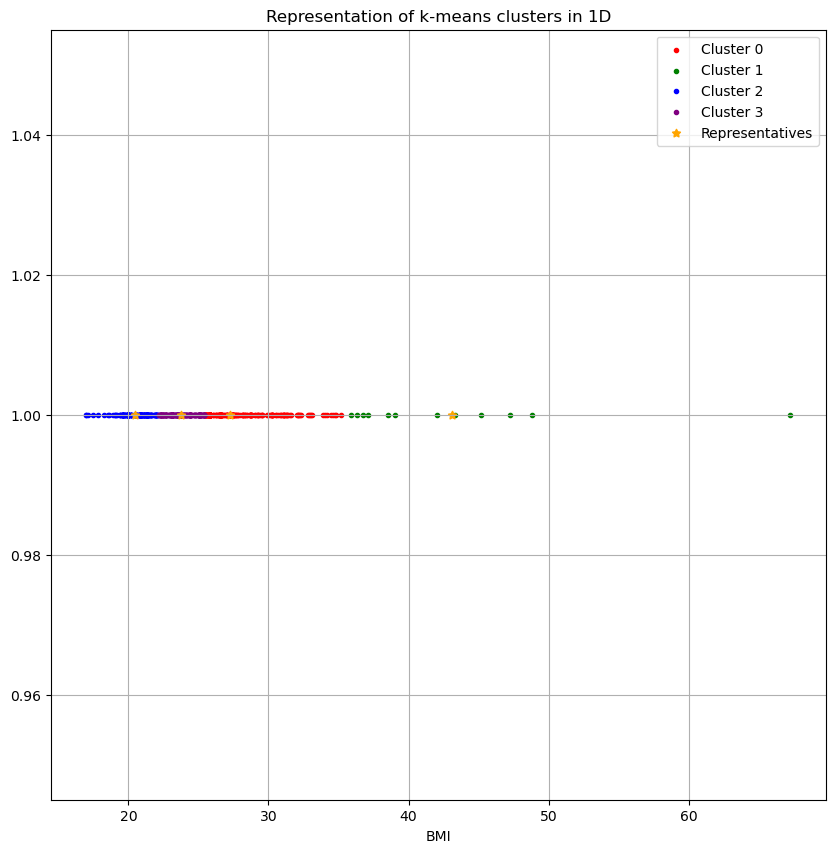

Function 'plotKmeans' executed in 0.2351 seconds


In [33]:
utils.plotKmeans(data['BMI'], utils.applyKmeans(data['BMI'], 4), ['red', 'green', 'blue', 'purple'])

Function 'applyKmeans' executed in 0.0929 seconds


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


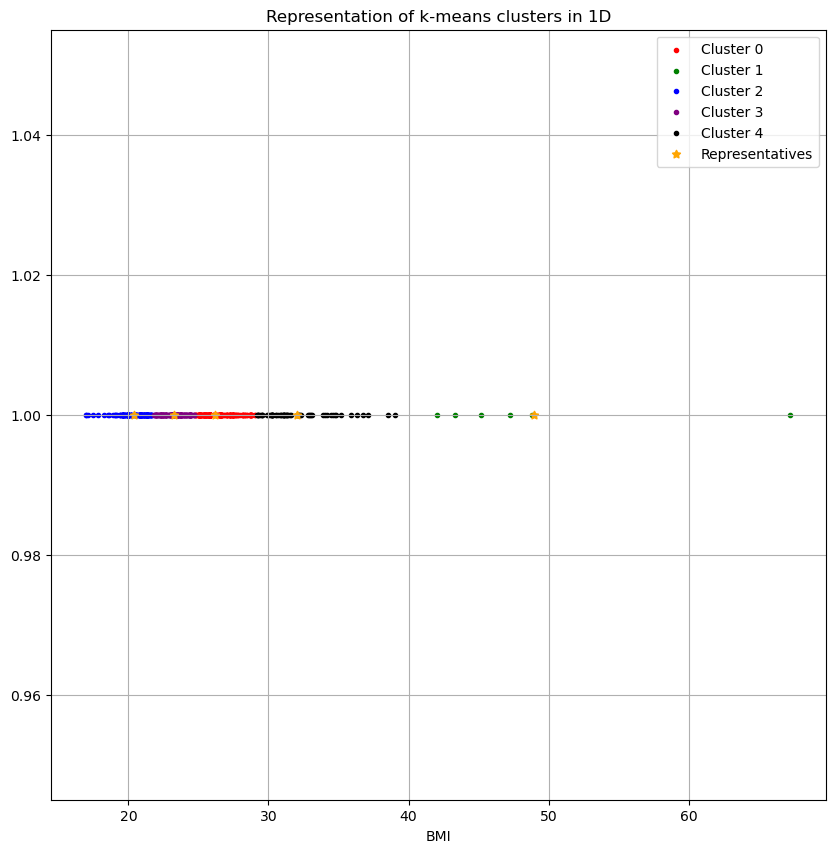

Function 'plotKmeans' executed in 0.2625 seconds


In [34]:
utils.plotKmeans(data['BMI'], utils.applyKmeans(data['BMI'], 5), ['red', 'green', 'blue', 'purple', 'black'])

<hr>

As was to be expected the original J vs clusters chart was right. We can clearly see that any more clusters split existing ones instead of separating the outliers withe the rest of the data into seperate clusters (for reference the indicator is the purple cluster in the plots for $\geq 3$ clusters). 

A final reason might be the initialization of the clusters that lead to $4$ clusters not being the final descision, but our initialization strategy was apt.

These results do not coincide with the set BMI categories of the world health organization. Our clustering has taken a portion of the BMI scale set by thw WHO in the upper bound being from 'normal' to 'obese'.

Now we can move past he clusters we got from the k-means. We wont be writing a wrapper function in ```funcitons.py``` for all the clustering methods, only ploting functions.

<hr>

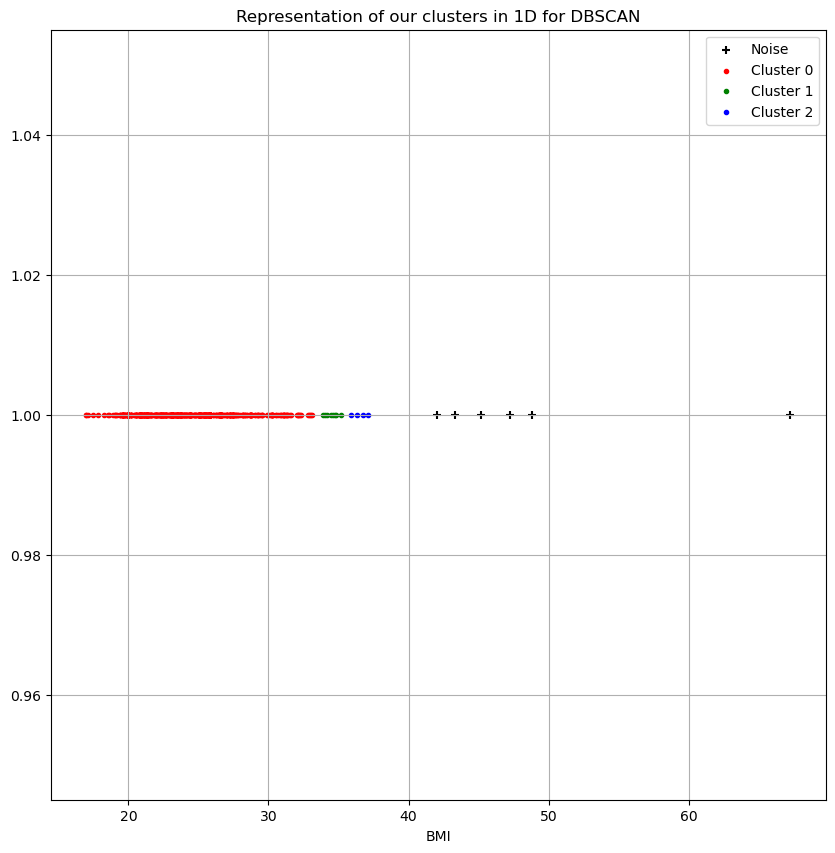

Function 'plotDbscan' executed in 0.1992 seconds


In [35]:
# DBSCAN
from sklearn.cluster import dbscan

cores, labels = dbscan(data['BMI'].values.reshape(-1,1), 0.6, min_samples = 2)
del cores
utils.plotDbscan(data['BMI'], labels)

<hr>

As expected the density based clustering algorithms cannor separate the clusters properly since they are of a compact ovelaping shape.

<hr>

C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


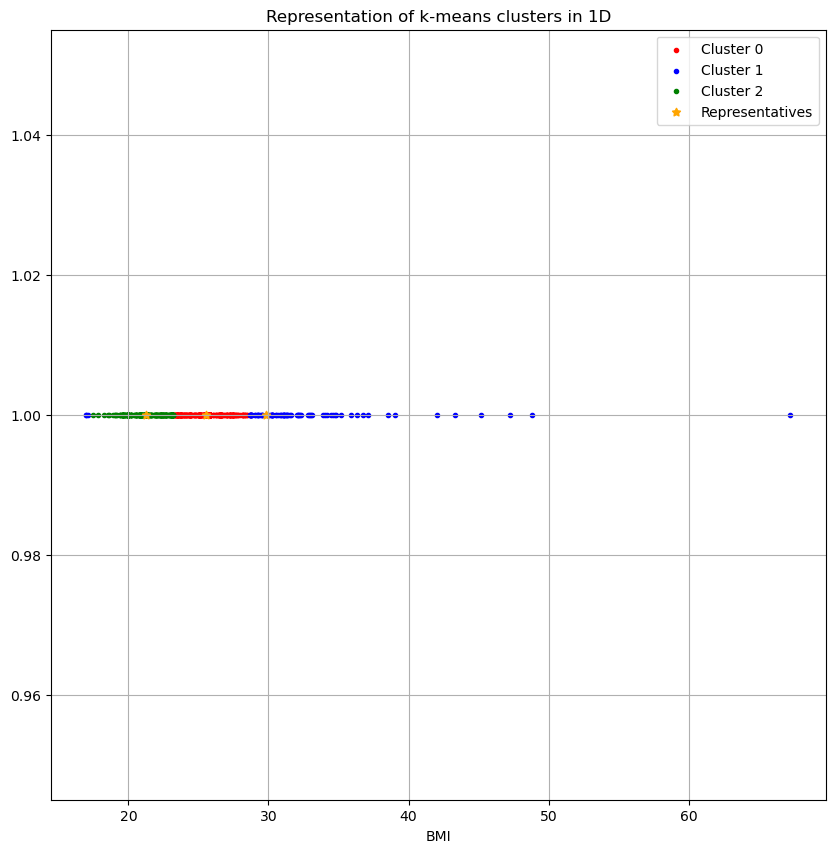

Function 'plotKmeans' executed in 0.2133 seconds


In [36]:
# Expectation Maximization
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state = 42)
output = gmm.fit(data['BMI'].values.reshape(-1, 1))
holder = output.predict(data['BMI'].values.reshape(-1, 1))
utils.plotKmeans(data['BMI'], (output.means_, holder), colors = ['red', 'blue', 'green']) # Funny how a naming choice snowballs later in the report
# I would love to plot the gaussina distribution ontop of the data but there will be no time in this assignment
del gmm
del output
del holder


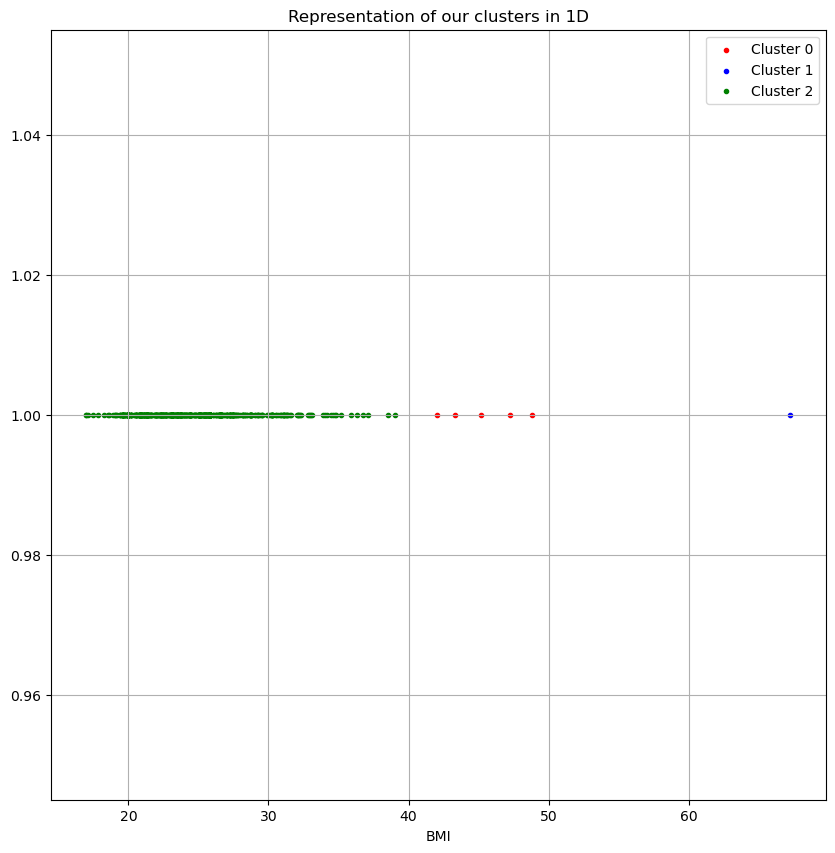

Function 'plotHierarchical' executed in 0.1900 seconds


In [37]:
# Single link\
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters = 3, linkage = 'single')
cluster.fit(data['BMI'].values.reshape(-1, 1))
utils.plotHierarchical(data['BMI'], cluster.labels_)
del cluster


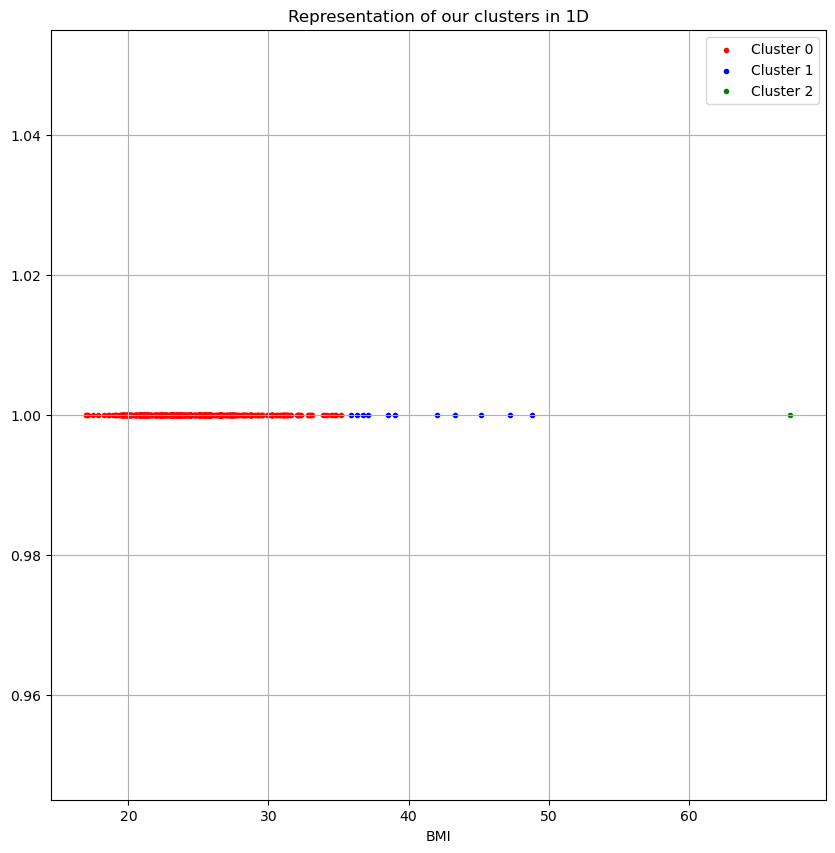

Function 'plotHierarchical' executed in 0.2029 seconds


In [38]:
# Complete link
cluster = AgglomerativeClustering(n_clusters = 3, linkage='complete')
cluster.fit(data['BMI'].values.reshape(-1, 1))
utils.plotHierarchical(data['BMI'], cluster.labels_)
del cluster


<hr>

# Characterization of the clusters

## Assumption validation

- The sinlge link performed better than expected but not well enough
- The complete link performed worse than expected
- DBSCAN indeed did not manage to separate the clusters well
- We had fewer clusters than the WHO categories
- We did not try a median based algorithm

The best clustering have been produced byt he k0means nad the Faussian mixture model. Between these two we will pick the k means sine the EM has classified some of the points in a non linear way (look to the start of the plot with the blue points being split into two). One cluster represents the very high values, one the above average and one the below average. This is to say for our data not vased ont he BMI scale of the WHO.

We will append the labels to all the rows nad use them to trian the calssification models below

# Baseline

We will choose 3 models to use for the classification task.

- KNN
- Naive Bayes classifier
- Support vector machines

<hr>

In [5]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, jaccard_score, precision_score, recall_score


C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\aPodo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Function 'applyKmeans' executed in 0.2315 seconds
Function 'applyKmeans' executed in 0.0877 seconds


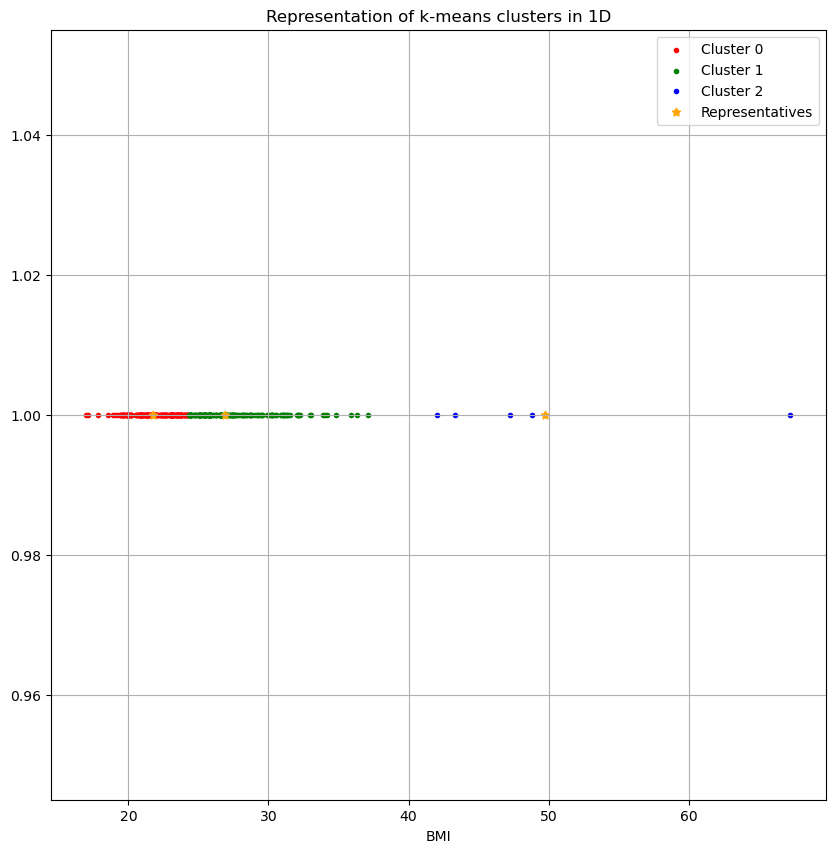

Function 'plotKmeans' executed in 0.2494 seconds


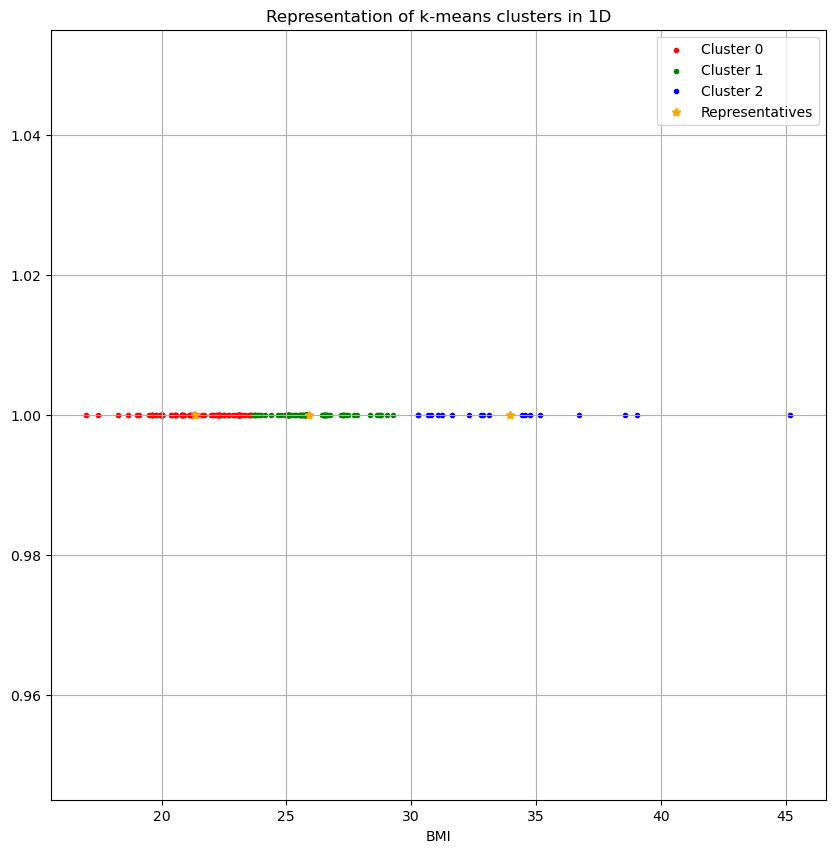

Function 'plotKmeans' executed in 0.1574 seconds


In [6]:
# Getting data into the proper format
# Generating data
trainLabels = utils.applyKmeans(devData['BMI'], 3) # we use dev data and val data to keep them seperate
valLabels = utils.applyKmeans(valData['BMI'], 3)
utils.plotKmeans(devData['BMI'], trainLabels)
utils.plotKmeans(valData['BMI'], valLabels)

trainLabels = pd.DataFrame({'Label': trainLabels[1]})
valLabels = pd.DataFrame({'Label': valLabels[1]})


In [7]:
devPca.insert(0, 'Label', trainLabels)
valPca.insert(0, 'Label', valLabels)


In [8]:
print(trainLabels)
print(valLabels)


     Label
0        0
1        0
2        1
3        0
4        0
..     ...
484      1
485      1
486      1
487      1
488      0

[489 rows x 1 columns]
     Label
0        1
1        1
2        0
3        1
4        0
..     ...
206      0
207      1
208      1
209      1
210      0

[211 rows x 1 columns]


In [9]:
devPca.head(100)


,Label,0,1,2,3,4,5,6,7,8,...,85,86,87,88,89,90,91,92,93,94
0,0,-1.849089,-0.140920,-1.266297,-0.145266,-0.301463,-0.185271,0.213756,-0.517308,-0.048592,...,0.123970,0.170621,-0.354964,0.045266,-0.038382,-0.016285,-0.029371,-0.259434,-0.052854,-0.128872
1,0,3.043090,10.763641,2.874763,-4.693270,-0.041211,-0.084973,-1.329089,-2.964214,1.211787,...,0.853981,0.112889,-0.410547,0.622230,0.798453,0.214674,-0.408864,1.077974,-0.788656,-0.528223
2,1,-2.403592,0.270338,-1.193480,-0.320505,-0.624223,-0.278452,-0.283442,-0.085687,-0.253455,...,0.019852,0.268311,-0.114725,-0.016287,-0.248290,0.059599,0.161361,0.267282,0.077818,-0.054439
3,0,0.610512,-0.157055,0.616014,1.940658,-0.451681,-1.180577,-0.962582,0.257780,0.158454,...,-0.709676,-0.949189,-0.670401,0.154740,-0.350549,2.171668,-0.275381,-0.637749,-0.614822,-0.220837
4,0,2.125645,-3.238797,-0.077841,-1.307018,-0.529641,-0.873104,-0.526120,-0.087158,-1.768089,...,0.481511,-0.104006,0.394107,-0.646282,-1.188266,0.232789,-0.613627,1.345919,-1.918396,0.882115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,2.642387,1.782696,-1.655648,5.656841,-0.167402,1.733027,4.579462,6.401641,2.446333,...,-1.246375,0.139396,-0.426018,-1.165473,0.434751,0.104766,0.558734,-0.876613,0.129921,0.814187
96,0,1.562491,0.954903,0.869319,2.512508,-0.071990,-0.049885,1.125159,1.234660,-0.940687,...,0.375994,0.273712,0.203566,-0.807048,-0.365122,-0.695082,-0.215215,-0.082340,0.129184,0.325069
97,1,3.996791,1.370423,0.796641,1.920177,-0.382074,-0.208073,-0.814907,-1.939726,-0.845843,...,0.477345,-1.236204,0.467245,-1.128856,-0.020288,0.672382,0.134096,0.052729,-1.150364,-0.225995
98,0,-0.422359,3.752193,-0.083443,-2.501801,0.079725,0.158974,-0.274221,0.901331,-0.048452,...,-0.975933,-0.274398,0.961864,0.137893,-0.174621,-0.116182,-1.337633,-0.180219,-0.253432,0.035590


In [10]:
valPca.head(100)


,Label,0,1,2,3,4,5,6,7,8,...,85,86,87,88,89,90,91,92,93,94
0,1,-1.449254,-0.118120,0.192261,-0.252096,0.020092,0.036432,0.208829,-0.453389,-1.233135,...,0.546344,-0.060728,0.075999,-0.025645,-0.040778,0.419661,-0.222014,0.354806,-0.048871,-0.338722
1,1,-1.365614,-0.071044,-1.520152,-0.453508,-1.362667,-1.252783,-0.540205,0.147210,0.239817,...,0.017891,-0.023925,-0.081162,-0.036696,-0.105939,0.014606,-0.020344,-0.023393,-0.028802,-0.063492
2,0,-0.930474,0.309158,-1.145262,-0.074573,-0.112228,0.298727,4.198898,2.916844,-0.003848,...,0.058915,0.339861,-0.241391,0.430265,-0.093608,-0.437303,0.039219,-0.249777,-0.266965,-0.178463
3,1,-1.370224,-0.071494,-0.995597,-0.402944,-1.396126,-1.222569,-0.405407,0.131836,-0.026556,...,0.022721,-0.016732,-0.139483,-0.140854,-0.036689,0.046905,-0.016968,0.061309,-0.026978,-0.100179
4,0,-1.365614,-0.071044,-1.520152,-0.453508,-1.362667,-1.252783,-0.540205,0.147210,0.239817,...,0.017891,-0.023925,-0.081162,-0.036696,-0.105939,0.014606,-0.020344,-0.023393,-0.028802,-0.063492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,-1.365614,-0.071044,-1.520152,-0.453508,-1.362667,-1.252783,-0.540205,0.147210,0.239817,...,0.017891,-0.023925,-0.081162,-0.036696,-0.105939,0.014606,-0.020344,-0.023393,-0.028802,-0.063492
96,1,-1.393801,-0.139367,-0.397250,-0.323176,0.608293,0.817336,-1.021062,-1.724233,-0.122923,...,-0.752980,0.297846,0.482547,-0.311795,-0.216968,-0.049290,0.738436,0.278847,-0.015017,-0.342876
97,1,-1.411453,-0.345011,1.497776,-0.235661,3.521551,2.588908,0.602107,-1.040925,-0.240695,...,-0.276046,-0.210266,0.100714,-0.332976,0.541121,0.118219,-0.719712,0.234190,-0.322878,0.210338
98,1,-1.396215,-0.091242,-1.239235,-0.503122,-0.865430,-1.129953,-0.243263,0.125702,0.231318,...,-0.028054,-0.142473,-0.109489,-0.058667,-0.016119,0.084504,-0.075422,-0.179545,-0.168791,0.199234


Function 'isolator' executed in 0.0005 seconds
Function 'isolator' executed in 0.0000 seconds
Function 'regressions' executed in 0.1240 seconds
Function 'applyMetrics' executed in 0.0252 seconds


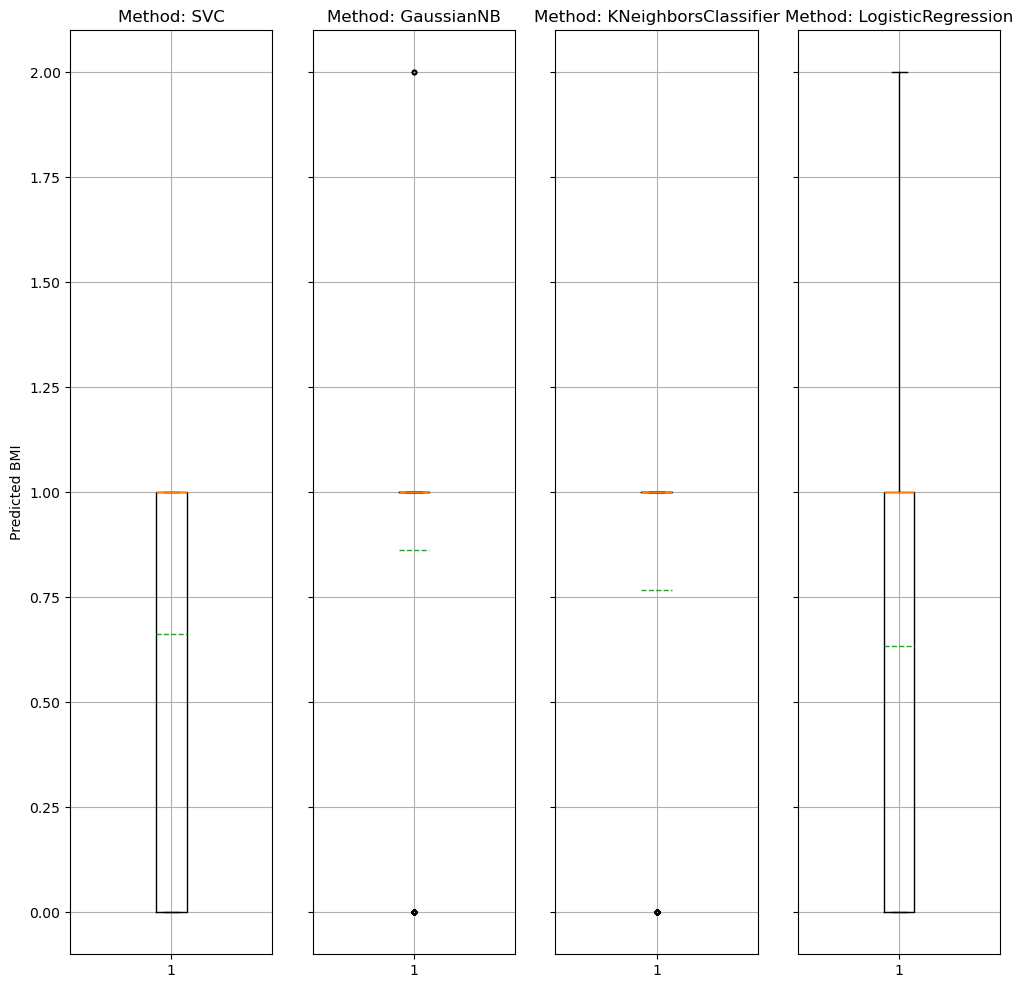

Function 'visualisePredictions' executed in 0.3075 seconds


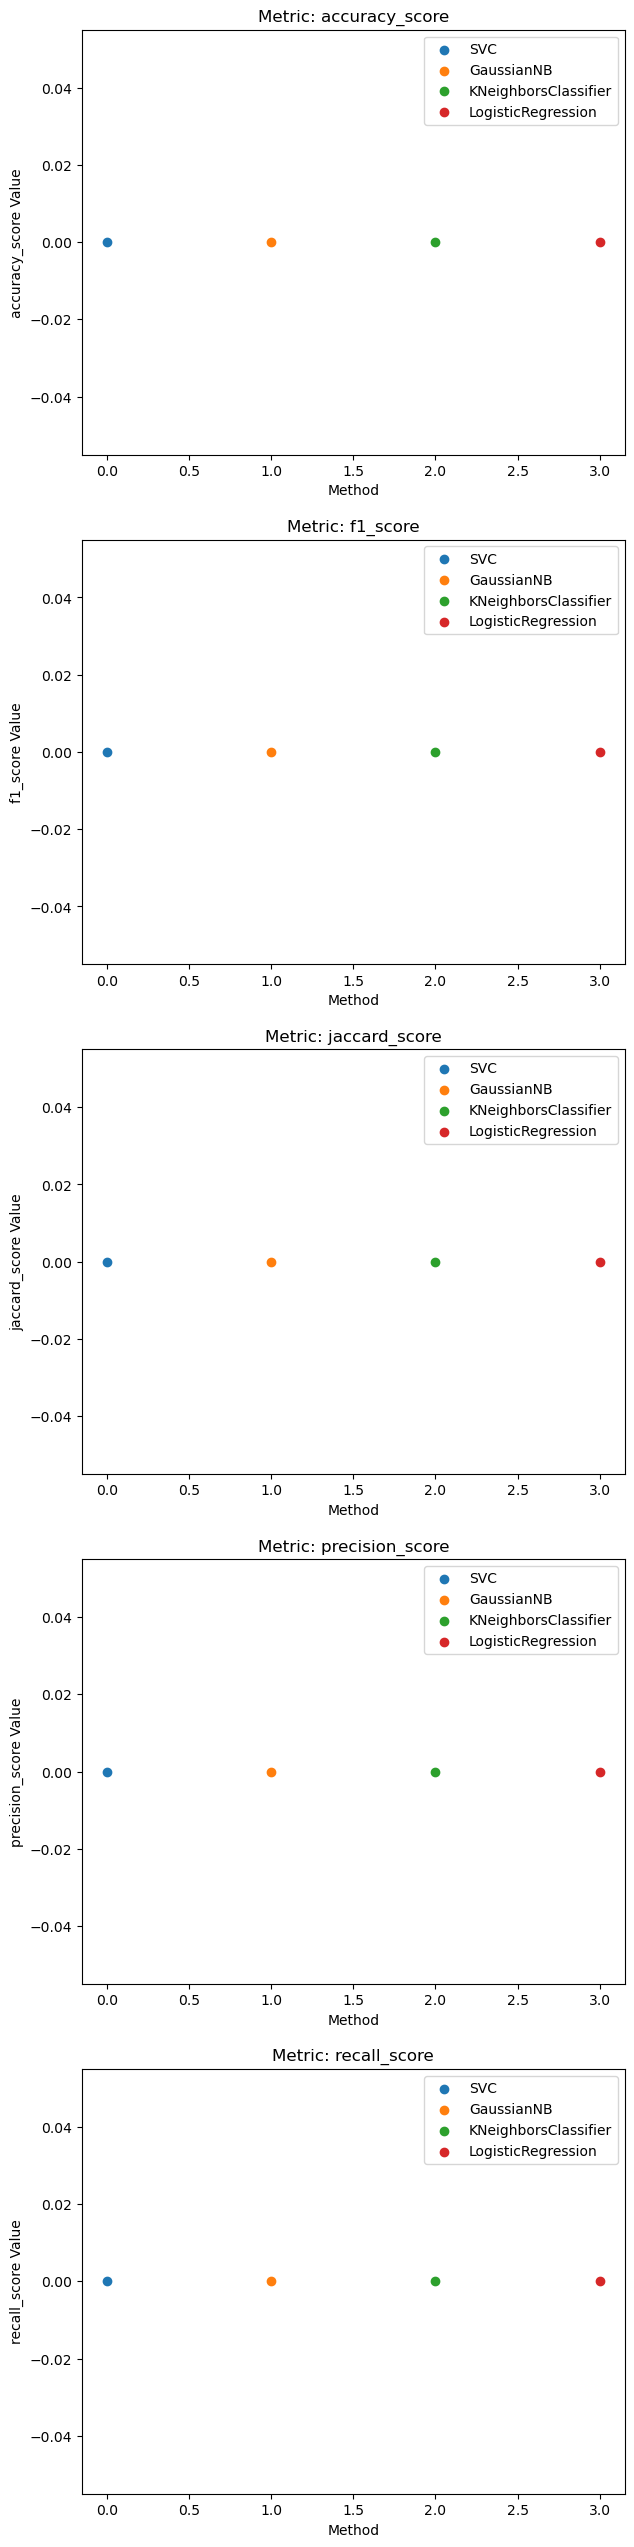

Function 'visualiseEvaluations' executed in 0.7493 seconds


In [12]:
# Establishing a baseline
methods = np.array([SVC, GaussianNB, KNeighborsClassifier, LogisticRegression])
metrics = np.array([accuracy_score, f1_score, jaccard_score, precision_score, recall_score]) # Keeping true to my format
# I grew attached to it actually I like that it is dynamic

train, preds = utils.isolator(devPca, 'Label')
val, truth = utils.isolator(valPca, 'Label')
# The funny thing is that the previous notebook functions work despite the bad names
holder = utils.regressions(methods, train, preds, val)
argDict = {'average': 'macro', 'zero_division': 1.0}
outputs = utils.applyMetrics(metrics, methods, truth.values, holder, arguments = [{}, argDict, argDict, argDict, argDict])
utils.visualisePredictions(holder, methods)
utils.visualiseEvaluations(outputs, methods, metrics)
del holder
del outputs


<hr>

the output labels dont form a well shaped distribution for the boxplots so we will omit them later

The metrics ...

<hr>

1000it [01:58,  8.45it/s]


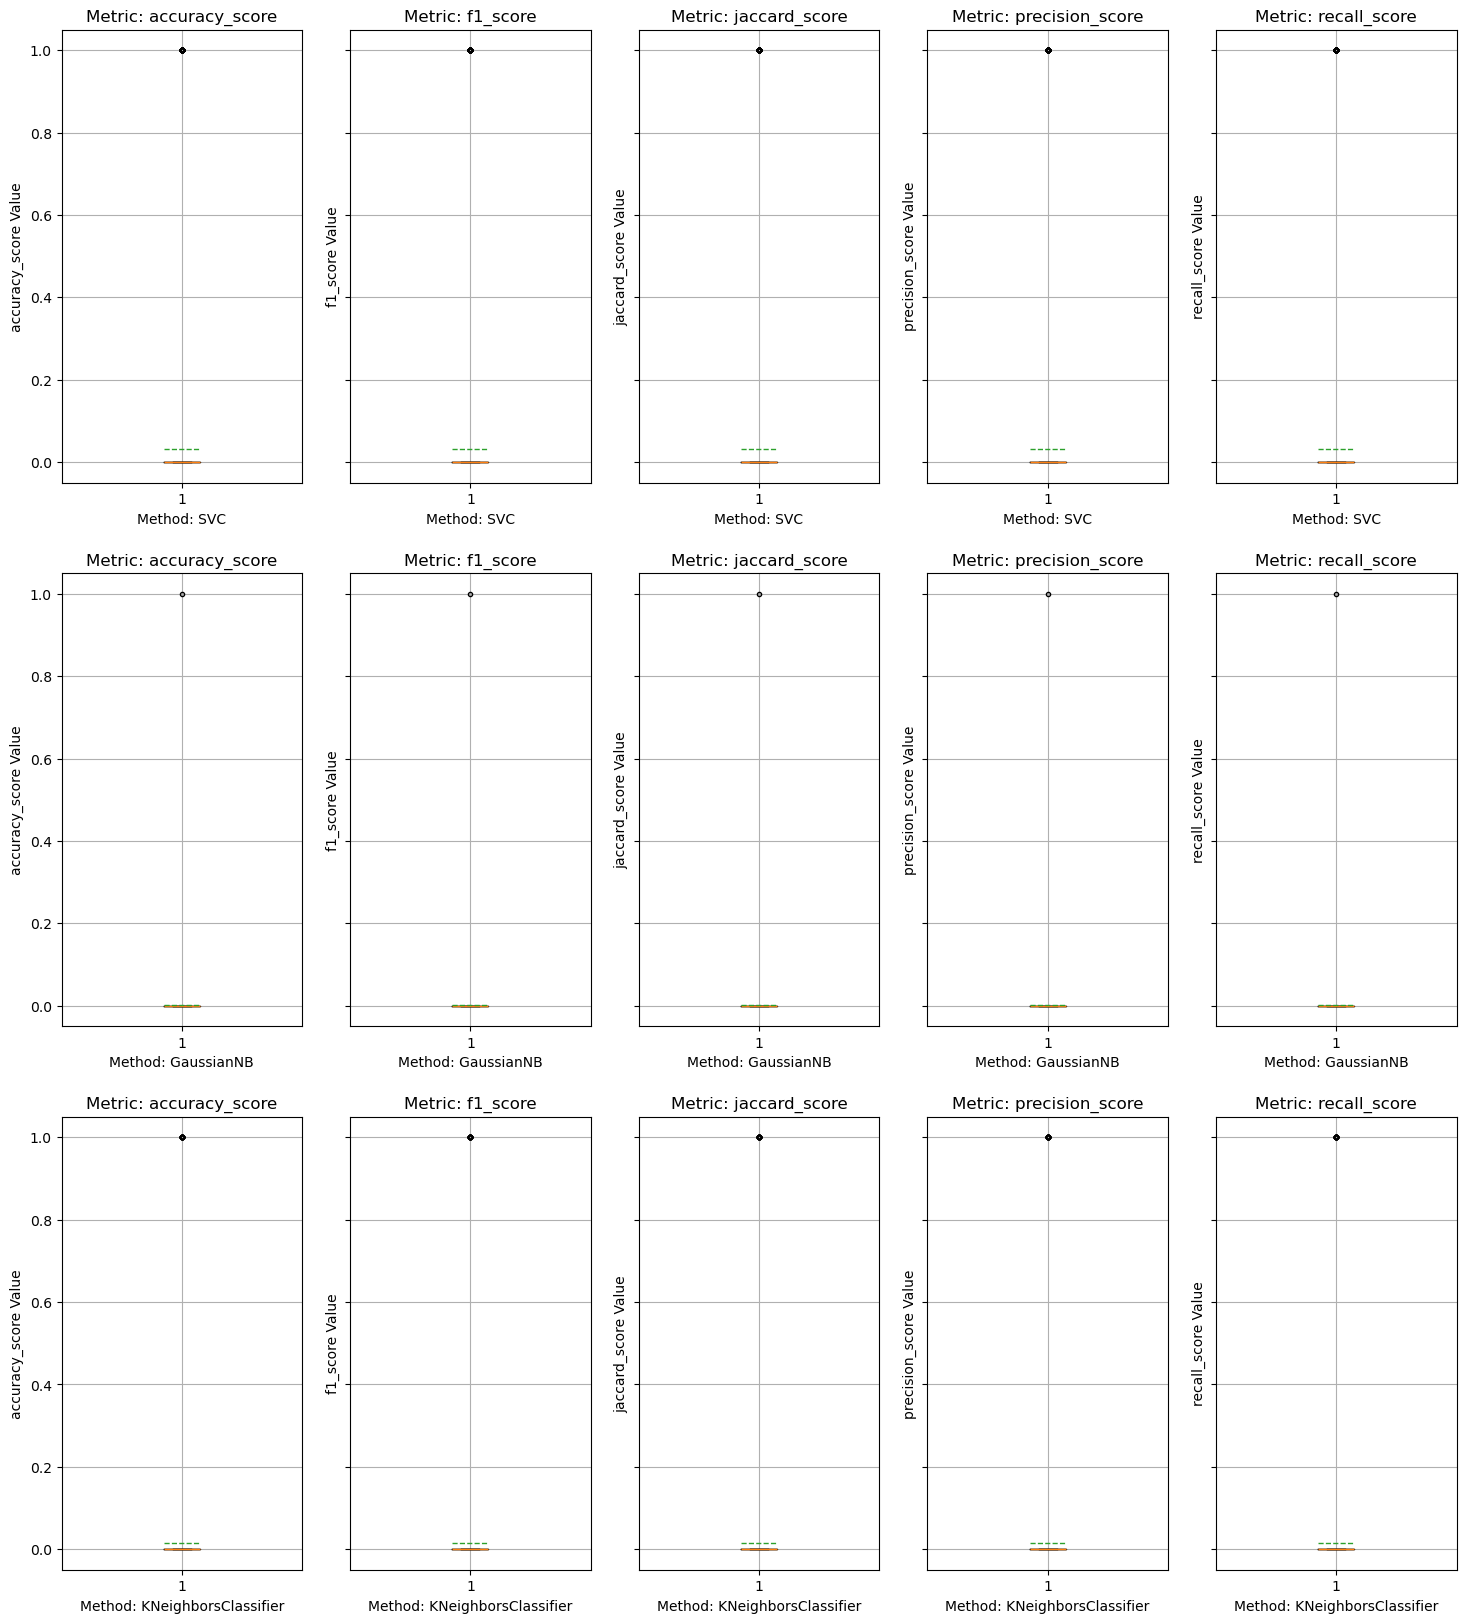

Function 'applyKfold' executed in 119.3878 seconds


array([[[[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]]],


       ...,


       [[[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0]],

        [[0],
         [0],
         [0]],

        [[

In [10]:
holder = utils.applyKfold(train, preds, methods, metrics, 50, 20, metarguments = [{}, argDict, argDict, argDict, argDict])


<hr>

Here we can see that the models are not perfect yet since the average values does not lie exactly on the 0 mark for all metrics as it did when we had simply applied the model to the data once as one split into dev and validation.

We have already done feature selection on this data so our baseline is the feature selected model, now we only have the hyperparameter optimization to do.

<hr>

In [16]:
holder1 = utils.optimizeSvc(f1_score, train, preds, val, truth, arguments = argDict)
holder2 = utils.optimizeKNN(f1_score, train, preds, val, truth, arguments = argDict)
holder3 = utils.optimizeNBC(f1_score, train, preds, val, truth, arguments = argDict)
holder4 = utils.optimizeLR(f1_score, train, preds, val, truth, arguments = argDict)
methodArgs = [holder1, holder3, holder2, holder4] # I called them in the wrong order...


[I 2025-03-28 13:48:06,998] A new study created in memory with name: no-name-0bf6104e-1bbf-4af4-90bf-3a4135ce3998
[I 2025-03-28 13:48:07,388] Trial 0 finished with value: 0.2581479640258508 and parameters: {'C': 4.1342953787673515, 'gamma': 'scale', 'kernel': 'linear', 'degree': 3, 'coef0': 0.21945765128114647}. Best is trial 0 with value: 0.2581479640258508.
[I 2025-03-28 13:48:07,408] Trial 1 finished with value: 0.25984071243315204 and parameters: {'C': 0.8508610051061941, 'gamma': 'scale', 'kernel': 'poly', 'degree': 5, 'coef0': 0.25307749445568606}. Best is trial 0 with value: 0.2581479640258508.
[I 2025-03-28 13:48:07,428] Trial 2 finished with value: 0.307828376321527 and parameters: {'C': 1.4403880589461249, 'gamma': 'scale', 'kernel': 'poly', 'degree': 3, 'coef0': 0.33134502208837247}. Best is trial 0 with value: 0.2581479640258508.
[I 2025-03-28 13:48:07,447] Trial 3 finished with value: 0.33080871133305595 and parameters: {'C': 3.4020831118799877, 'gamma': 'scale', 'kernel':

Function 'optimizeSvc' executed in 30.8967 seconds


[I 2025-03-28 13:48:38,117] Trial 2 finished with value: 0.27076953278366706 and parameters: {'n_neighbors': 9, 'leaf_size': 30, 'weights': 'uniform', 'algorithm': 'brute'}. Best is trial 2 with value: 0.27076953278366706.
[I 2025-03-28 13:48:38,190] Trial 3 finished with value: 0.27076953278366706 and parameters: {'n_neighbors': 9, 'leaf_size': 31, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 2 with value: 0.27076953278366706.
[I 2025-03-28 13:48:38,234] Trial 4 finished with value: 0.3250661192180362 and parameters: {'n_neighbors': 6, 'leaf_size': 29, 'weights': 'uniform', 'algorithm': 'kd_tree'}. Best is trial 2 with value: 0.27076953278366706.
[I 2025-03-28 13:48:38,254] Trial 5 finished with value: 0.3125722166312572 and parameters: {'n_neighbors': 5, 'leaf_size': 33, 'weights': 'distance', 'algorithm': 'ball_tree'}. Best is trial 2 with value: 0.27076953278366706.
[I 2025-03-28 13:48:38,334] Trial 6 finished with value: 0.31094327494777435 and parameters: {'n_neigh

Function 'optimizeKNN' executed in 6.7927 seconds


[I 2025-03-28 13:48:44,867] Trial 17 finished with value: 0.3030138528660756 and parameters: {'var_smoothing': 6.564265982230291e-07}. Best is trial 0 with value: 0.3030138528660756.
[I 2025-03-28 13:48:44,876] Trial 18 finished with value: 0.3030138528660756 and parameters: {'var_smoothing': 4.220728917335462e-07}. Best is trial 0 with value: 0.3030138528660756.
[I 2025-03-28 13:48:44,885] Trial 19 finished with value: 0.3030138528660756 and parameters: {'var_smoothing': 5.384760834669459e-07}. Best is trial 0 with value: 0.3030138528660756.
[I 2025-03-28 13:48:44,895] Trial 20 finished with value: 0.3030138528660756 and parameters: {'var_smoothing': 1.6408999941618094e-07}. Best is trial 0 with value: 0.3030138528660756.
[I 2025-03-28 13:48:44,904] Trial 21 finished with value: 0.3030138528660756 and parameters: {'var_smoothing': 9.723897543241257e-07}. Best is trial 0 with value: 0.3030138528660756.
[I 2025-03-28 13:48:44,913] Trial 22 finished with value: 0.3030138528660756 and par

Function 'optimizeNBC' executed in 0.9926 seconds


[I 2025-03-28 13:48:45,886] Trial 7 finished with value: 0.28669180282083506 and parameters: {'C': 0.2688215653790186}. Best is trial 1 with value: 0.24931581828133553.
[I 2025-03-28 13:48:45,911] Trial 8 finished with value: 0.2712228669675478 and parameters: {'C': 1.0064598745676248}. Best is trial 1 with value: 0.24931581828133553.
[I 2025-03-28 13:48:45,939] Trial 9 finished with value: 0.26434558349451964 and parameters: {'C': 1.3464402741776726}. Best is trial 1 with value: 0.24931581828133553.
[I 2025-03-28 13:48:45,965] Trial 10 finished with value: 0.27170824939304716 and parameters: {'C': 0.6555738053117692}. Best is trial 1 with value: 0.24931581828133553.
[I 2025-03-28 13:48:45,999] Trial 11 finished with value: 0.24931581828133553 and parameters: {'C': 1.9821806444425245}. Best is trial 1 with value: 0.24931581828133553.
[I 2025-03-28 13:48:46,032] Trial 12 finished with value: 0.24931581828133553 and parameters: {'C': 1.9937059194402067}. Best is trial 1 with value: 0.249

Function 'optimizeLR' executed in 3.2817 seconds


Function 'regressions' executed in 0.3111 seconds
Function 'applyMetrics' executed in 0.0261 seconds


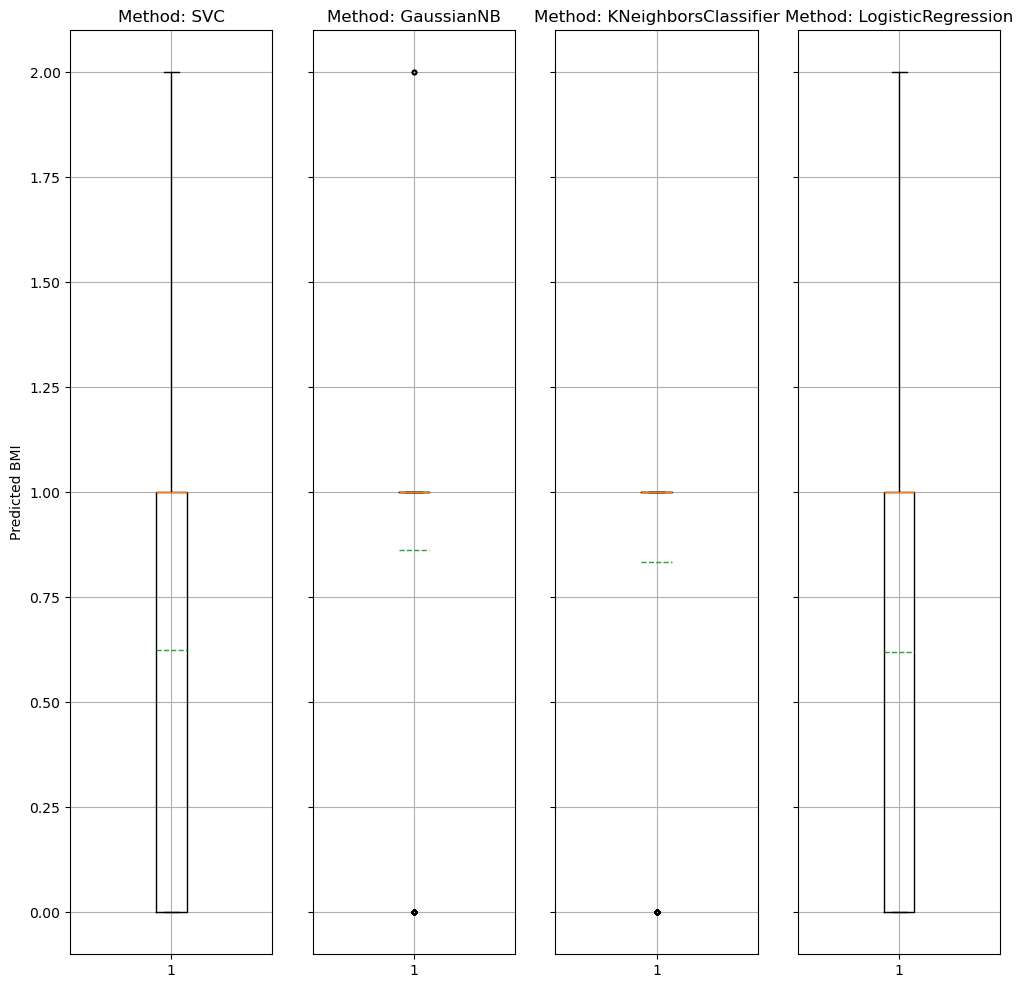

Function 'visualisePredictions' executed in 0.3180 seconds


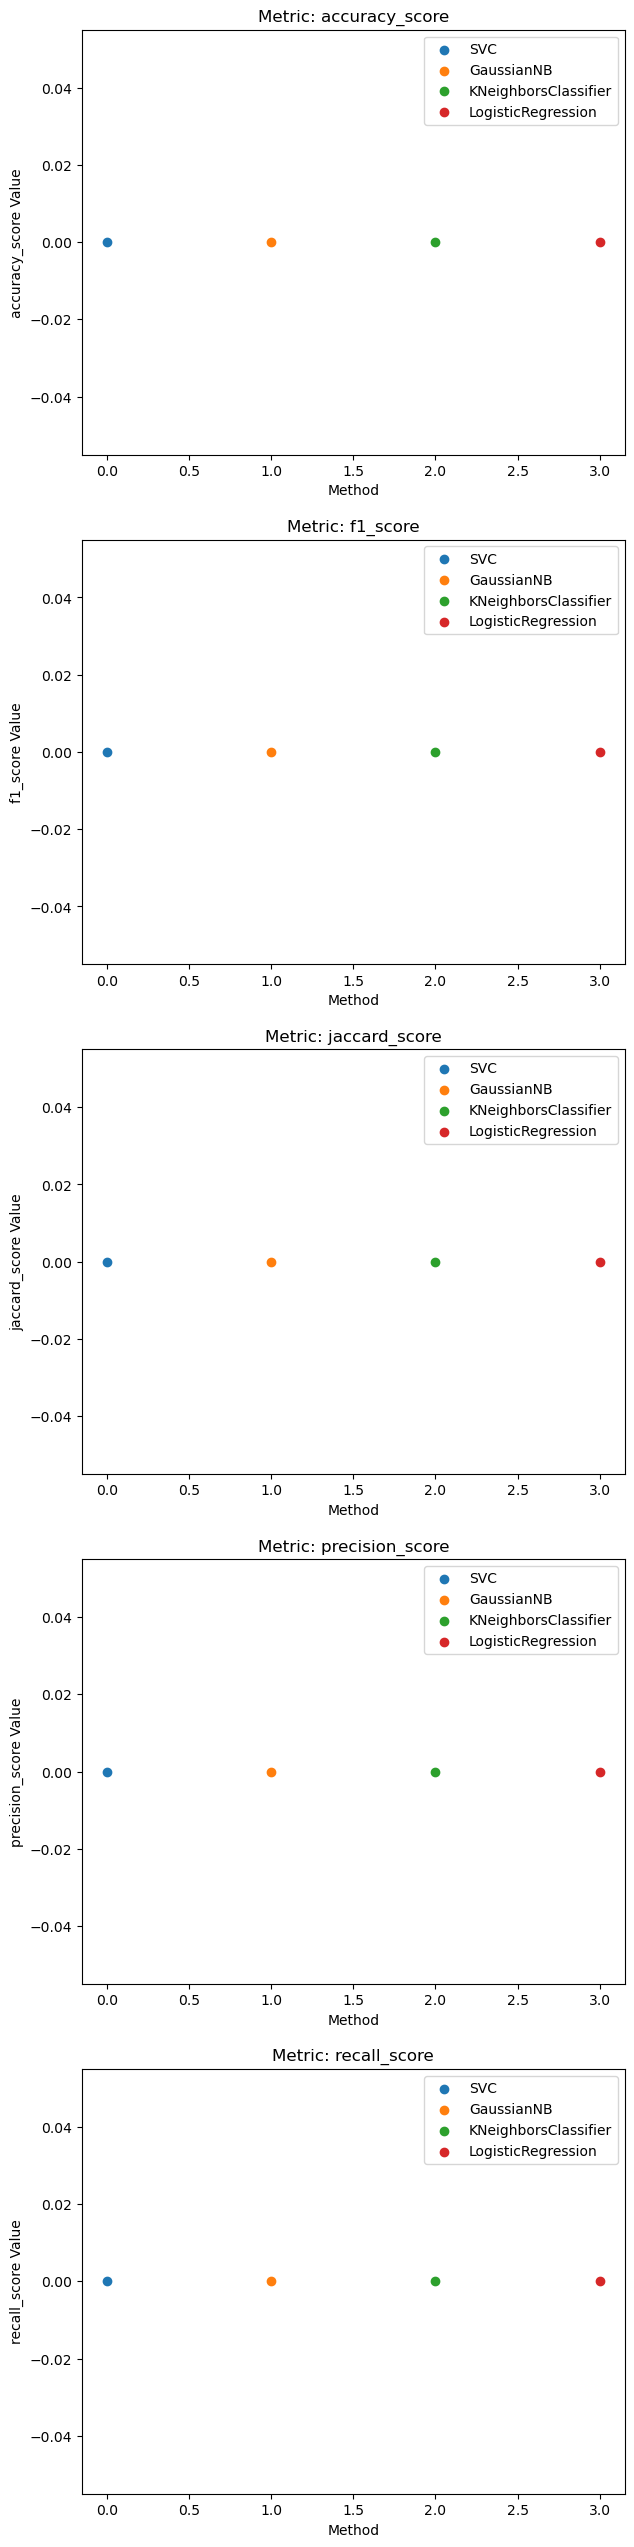

Function 'visualiseEvaluations' executed in 0.7572 seconds


In [17]:
holder = utils.regressions(methods, train, preds, val, arguments = methodArgs)
outputs = utils.applyMetrics(metrics, methods, truth.values, holder, arguments = [{}, argDict, argDict, argDict, argDict])
utils.visualisePredictions(holder, methods)
utils.visualiseEvaluations(outputs, methods, metrics)
del holder
del outputs


<hr>

It would seem that the classification task is simply very simple for our models judging by the metrics for each of the models.

<hr>